# Zero-padded and non zero-padded Angular Spectrum Method (ASM) comparison

In this example we will compare two implementations of the Angular Spectrum Method (ASM) for simulating wave propagation: one with zero-padding and one without. We will analyze the differences in the results obtained from both methods and discuss the advantages and disadvantages of each approach

We will compare the results of the two methods by visualizing the propagated wave fields and calculating the error between obtained intensity distribution and the expected intensity distribution given by the analytical solution. 

We will numerically calculate the intensity distribution of the plane wave after propagating through the square aperture in the Fresnel region. The analytical solution for the intensity distribution is expressed in terms of the Fresnel integrals, which can be computed using the `scipy.special.fresnel` function:
$$
I(x,y)=\frac{1}{4}\left|\text{C}\left(\sqrt{\frac{2}{\lambda z}}\left(x+\frac{a}{2}\right)\right)-\text{C}\left(\sqrt{\frac{2}{\lambda z}}\left(x-\frac{a}{2}\right)\right)\right|^2 \cdot \left|\text{S}\left(\sqrt{\frac{2}{\lambda z}}\left(y+\frac{a}{2}\right)\right)-\text{S}\left(\sqrt{\frac{2}{\lambda z}}\left(y-\frac{a}{2}\right)\right)\right|^2,
$$
where
$$
C(x) = \int_0^x \cos\left(\frac{\pi t^2}{2}\right) dt, \quad S(x) = \int_0^x \sin\left(\frac{\pi t^2}{2}\right) dt.
$$

Firstly, we will make the function to compute the analytical solution for the intensity distribution

In [57]:
import torch

from svetlanna.elements import RectangularAperture, FreeSpace
from svetlanna import SimulationParameters
from svetlanna import Wavefront
from svetlanna.units import ureg

import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
import tqdm

In [58]:
def analytical_solution(x, y, nx, ny, a, z, wavelength):
    x_linear = np.linspace(-x / 2, x / 2, nx)
    y_linear = np.linspace(-y / 2, y / 2, ny)
    x_grid, y_grid = np.meshgrid(x_linear, y_linear)

    wave_number = 2 * np.pi / wavelength
    x_grid = x_grid[None, :]
    y_grid = y_grid[None, :]

    psi1 = -np.sqrt(wave_number / (np.pi * z)) * (a / 2 + x_grid)
    psi2 = np.sqrt(wave_number / (np.pi * z)) * (a / 2 - x_grid)
    eta1 = -np.sqrt(wave_number / (np.pi * z)) * (a / 2 + y_grid)
    eta2 = np.sqrt(wave_number / (np.pi * z)) * (a / 2 - y_grid)

    s_psi1, c_psi1 = sp.special.fresnel(psi1)
    s_psi2, c_psi2 = sp.special.fresnel(psi2)
    s_eta1, c_eta1 = sp.special.fresnel(eta1)
    s_eta2, c_eta2 = sp.special.fresnel(eta2)

    field = (
        np.exp(1j * wave_number * z)
        * (1 / 2j)
        * ((c_psi2 - c_psi1) + 1j * (s_psi2 - s_psi1))
        * ((c_eta2 - c_eta1) + 1j * (s_eta2 - s_eta1))
    )
    return np.abs(field[0]) ** 2

Secondly, we will create the computational grid and define the parameters for the simulation, such as the wavelength, aperture size, and propagation distance

In [59]:
lx = 5 * ureg.mm  # size along x-axis
ly = 5 * ureg.mm  # size along y-axis
Nx = 100  # number of nodes along x-axis
Ny = 100  # number of nodes along y-axis

z = 480 * ureg.mm  # propagation distance, mm

wl = 1064 * ureg.nm  # wavelength of the wavefront, nm

params = SimulationParameters(
    {
        "x": torch.linspace(-lx / 2, lx / 2, Nx),
        "y": torch.linspace(-ly / 2, ly / 2, Ny),
        "wavelength": wl,
    }
)

x_grid, y_grid = params.meshgrid(x_axis="W", y_axis="H")  # create computational grid

Thirdly, we will create the plane wave as the incident wavefront and apply the square aperture to it

In [60]:
initial_wavefront = Wavefront.plane_wave(
    simulation_parameters=params, distance=10 * ureg.mm, wave_direction=[0, 0, 1]
)

a = 1 * ureg.mm  # width of the rectangular aperture, mm


rect = RectangularAperture(simulation_parameters=params, width=a, height=a)

transmitted_wavefront = rect.forward(initial_wavefront)

Fourthly, we will then propagate the wavefront using both the zero-padded and non zero-padded ASM methods

In [61]:
methods = ["zpASM", "ASM"]

intensity_distributions = {}

for method in tqdm.tqdm(methods):
    free_space = FreeSpace(simulation_parameters=params, distance=z, method=method)
    output_wavefront = free_space.forward(transmitted_wavefront)
    output_intensity = output_wavefront.intensity
    intensity_distributions[method] = output_intensity

100%|██████████| 2/2 [00:00<00:00, 176.60it/s]


Finally, we will calculate the analytical solution and compare it with the results obtained from both methods by visualizing the intensity distributions

In [62]:
intensity_analytical = analytical_solution(lx, ly, Nx, Ny, a, z, wl)

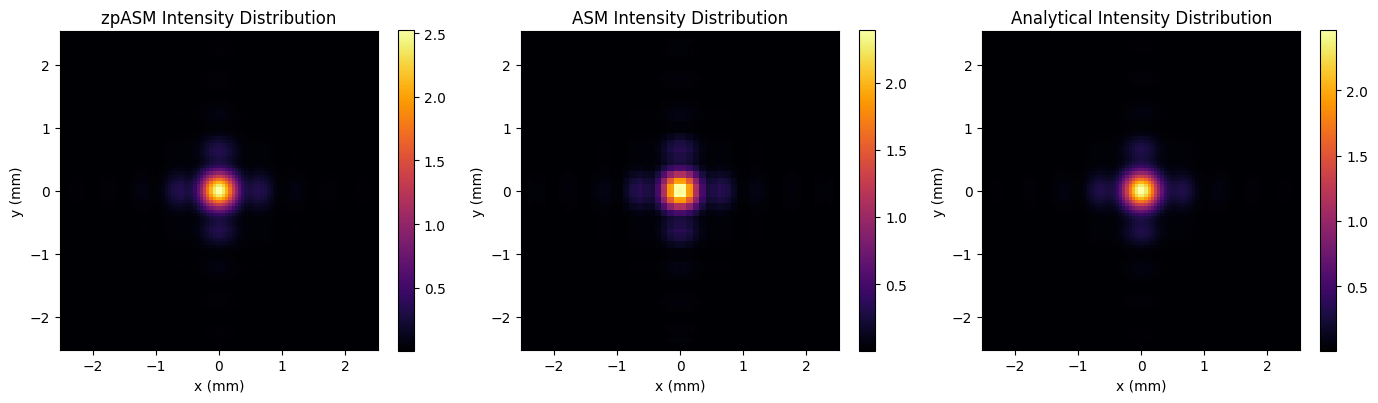

In [63]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))

for i, method in enumerate(methods):
    im = ax[i].pcolormesh(
        x_grid * 1e3,
        y_grid * 1e3,
        intensity_distributions[method].numpy(),
        shading="auto",
        cmap="inferno",
    )
    ax[i].set_title(f"{method} Intensity Distribution")
    ax[i].set_xlabel("x (mm)")
    ax[i].set_ylabel("y (mm)")
    ax[i].set_aspect("equal")
    fig.colorbar(im, ax=ax[i])

im = ax[2].pcolormesh(
    x_grid * 1e3, y_grid * 1e3, intensity_analytical, shading="auto", cmap="inferno"
)
ax[2].set_title("Analytical Intensity Distribution")
ax[2].set_xlabel("x (mm)")
ax[2].set_ylabel("y (mm)")
ax[2].set_aspect("equal")
fig.colorbar(im, ax=ax[2])
plt.tight_layout()

You can observe that Angular Spectrum Method with zero-padding provides a more accurate representation of the propagated wave field. On the one hand, the zero-padding helps to mitigate the effects of aliasing and allows for a more accurate representation of the wavefront. However, it also increases the computational cost due to the larger grid size. 

On the other hand, the non zero-padded ASM is computationally more efficient but may introduce artifacts and inaccuracies in the propagated wavefront, especially when the resolution of computational grid is not sufficient to capture the details of the wavefront.